# Purpose

Show relationship between brain co-expression performance and performance from brain composition-induced co-expression

In [1]:
import pandas as pd

In [2]:
def load_learnability(path:str)->pd.DataFrame:
	"""Load a dataframe containing info about a GO term's learnability from composition-induced co-expression

	Args:
		path (str): file path

	Returns:
		pd.DataFrame: df
	"""
	df = pd.read_csv(path,index_col=0)

	# extract and drop some metadata columns
	df['exp_type'] =df.organism_part.str.split("_").str.get(0)
	df['tissue'] =  df.organism_part.str.split("_").str.get(1)

	df = df[df['tissue']=='brain']
	df = df[df.loc[:,'variance']==0.05]
	df = df[df.loc[:,'exp_type']=='exp']

	df.drop('organism_part', axis =1 , inplace=True)
	df.drop('variance', axis =1 , inplace=True)

	return df
	
path = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/bulkSimulationOneProfile/data/boot_run_feb29/master_melted_df.csv.gz"
df = load_learnability(path)
df.head()

,index,bootstrap,auc,exp_type,tissue
1397,GO:0000045,3,0.537387,exp,brain
1398,GO:0000070,3,0.459143,exp,brain
1399,GO:0000077,3,0.468561,exp,brain
1400,GO:0000079,3,0.487572,exp,brain
1401,GO:0000082,3,0.488269,exp,brain


In [3]:
def load_bulk(path:str) -> pd.DataFrame:
	df = pd.read_csv(path, index_col=0)
	return df
	
bulk = load_bulk("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/bulkEGADPipeline/data/splitOPs1/EGAD/melted_dfs/Brain_split.csv_melted_EGADs.csv.gz")

In [4]:
def load_GO_curations(patho_to_curations="/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/preprocessing/preprocessGO_pipe/data/2024_march/data/GOCurations.tsv"):
	GO_curations = pd.read_csv(patho_to_curations, sep = "\t")

	def melt_curations(df:pd.DataFrame)->pd.DataFrame:
		"""
		create a new column that is a melted version of the GO term curations

		Parameters:
		- df: pandas DataFrame

		Returns:
		- pandas DataFrame with a new column 'meta' indicating the curation category of the GO term
		"""
		# Create a new column using conditions
		meta = df.apply(lambda row: 'Brain' if row['BrainAffiliated'] == 'T' else 'Non Brain', axis = 1)
		df['meta']=meta
		
		return df
	GO_curations = melt_curations(GO_curations)
	return GO_curations

GO_curations = load_GO_curations()
GO_curations.meta.value_counts()

meta
Non Brain    1294
Brain         102
Name: count, dtype: int64

### Merge

In [5]:
def merge(df, bulk,GO_curations):
	merged = pd.merge(df, bulk, on=['index','bootstrap'], suffixes=['_sim', "_bulk"])
	merged = pd.merge(merged, GO_curations, left_on = 'index', right_on='id')
	return merged

merged = merge(df, bulk, GO_curations)
merged.head()

,index,bootstrap,auc_sim,exp_type,tissue,auc_bulk,id,name,namespace,CTAffiliated,BrainAffiliated,PBMCAffiliated,def,meta
0,GO:0000045,3,0.537387,exp,brain,0.524639,GO:0000045,autophagosome assembly,biological_process,F,F,F,The formation of a double membrane-bounded str...,Non Brain
1,GO:0000045,5,0.563274,exp,brain,0.508492,GO:0000045,autophagosome assembly,biological_process,F,F,F,The formation of a double membrane-bounded str...,Non Brain
2,GO:0000045,1,0.558774,exp,brain,0.585574,GO:0000045,autophagosome assembly,biological_process,F,F,F,The formation of a double membrane-bounded str...,Non Brain
3,GO:0000045,4,0.554706,exp,brain,0.547592,GO:0000045,autophagosome assembly,biological_process,F,F,F,The formation of a double membrane-bounded str...,Non Brain
4,GO:0000045,2,0.535530,exp,brain,0.501083,GO:0000045,autophagosome assembly,biological_process,F,F,F,The formation of a double membrane-bounded str...,Non Brain


### mixed effect model

In [6]:
from statsmodels.formula.api import mixedlm
merged['meta'] = pd.Categorical(merged['meta'], ordered=True, categories=['Non Brain','Brain'])
merged['auc_sim_pow2'] = merged['auc_sim']**2
merged = merged.loc[:,['id','bootstrap','auc_sim','auc_bulk','auc_sim_pow2', 'meta']]
merged

,id,bootstrap,auc_sim,auc_bulk,auc_sim_pow2,meta
0,GO:0000045,3,0.537387,0.524639,0.288785,Non Brain
1,GO:0000045,5,0.563274,0.508492,0.317278,Non Brain
2,GO:0000045,1,0.558774,0.585574,0.312228,Non Brain
3,GO:0000045,4,0.554706,0.547592,0.307698,Non Brain
4,GO:0000045,2,0.535530,0.501083,0.286792,Non Brain
...,...,...,...,...,...,...
136295,GO:2001244,93,0.516547,0.670127,0.266821,Non Brain
136296,GO:2001244,96,0.542822,0.662114,0.294656,Non Brain
136297,GO:2001244,97,0.426631,0.699755,0.182014,Non Brain
136298,GO:2001244,100,0.464323,0.665889,0.215595,Non Brain


In [7]:
model = mixedlm(formula = 'auc_bulk ~ auc_sim *meta', data = merged, groups = merged['bootstrap']).fit()
model.summary()

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
=================================================================
Model:                MixedLM   Dependent Variable:   auc_bulk   
No. Observations:     136300    Method:               REML       
No. Groups:           100       Scale:                0.0067     
Min. group size:      1363      Log-Likelihood:       147704.2597
Max. group size:      1363      Converged:            Yes        
Mean group size:      1363.0                                     
-----------------------------------------------------------------
                      Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              0.497    0.002 249.134 0.000  0.493  0.501
meta[T.Brain]         -0.098    0.006 -17.061 0.000 -0.109 -0.087
auc_sim                0.191    0.004  50.065 0.000  0.183  0.198
auc_sim:meta[T.Brain]  0.207    0.011  19.544 0.000  0.187  0.228
Group Var              0.000    0.000                            
=================================================================

"""

/tmp/ipykernel_2810507/4011099558.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_agg = merged.groupby(['id', 'meta'])[['auc_sim', 'auc_bulk', 'pred']].mean().dropna().reset_index()
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/aadrian/miniforge3/envs/main

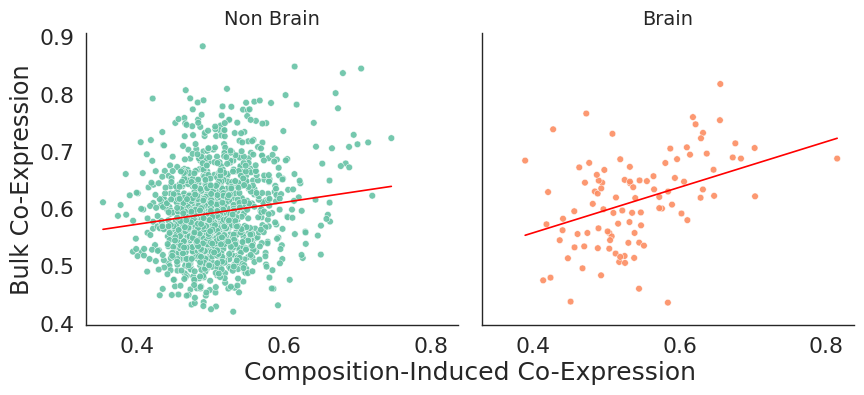

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot(merged, model):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd

    sns.set(style="white")
    sns.set_context("paper", font_scale=1.8)

    merged['pred'] = model.predict(merged)
    merged_agg = merged.groupby(['id', 'meta'])[['auc_sim', 'auc_bulk', 'pred']].mean().dropna().reset_index()

    # Set up the FacetGrid
    g = sns.FacetGrid(merged_agg, col='meta', col_wrap=2, height=4, aspect=1.2)

    # Scatterplot with hue
    g.map_dataframe(
        sns.scatterplot,
        x='auc_sim',
        y='auc_bulk',
        hue='meta',  # color by this column
        alpha=0.9,
        palette='Set2',  # You can choose another palette
        legend=False  # If you want a shared legend, set this to True and handle it below
    )

    # Lineplot without hue (assuming one red line per facet)
    g.map_dataframe(sns.lineplot, x='auc_sim', y='pred', color='red', legend=False)

    # Remove x-axis label, keep y-axis
    g.set_axis_labels("", "Bulk Co-Expression")

    # Remove facet titles
    g.set_titles(col_template="")
    # Add the label on the figure using g.fig.text()
    g.fig.text(0.5, 0.03, 'Composition-Induced Co-Expression', ha='center', va='center', fontsize=18)
    # Larger main title
    # Manually set different titles for each facet
    unique_metas = merged_agg['meta'].unique()
    custom_titles = {
        meta: f"{meta.replace('_', ' ').title()}"
        for meta in unique_metas
    }

    for ax, meta in zip(g.axes.flat, unique_metas):
        ax.set_title(custom_titles[meta], fontsize=14)

    # Adjust layout
    g.fig.subplots_adjust(top=0.88, bottom=0.15, left=0.1, right=0.9)

    sns.despine()
    plt.savefig("figs/bulk_sc_corr.svg", dpi = 300)
    plt.show()

plot(merged, model)


In [15]:
from scipy.stats import spearmanr

# Step 1: Group and aggregate
merged_agg = merged.groupby(['id', 'meta'])[['auc_sim', 'auc_bulk', 'pred']].mean().dropna().reset_index()

# Step 2: Filter for "Brain" meta
brain_data = merged_agg[merged_agg['meta'] == 'Brain']

# Step 3: Compute Spearman correlation and p-value
corr_coef, p_value = spearmanr(brain_data['auc_sim'], brain_data['auc_bulk'])

print(f"Spearman correlation: {corr_coef}")
print(f"P-value: {p_value}")


Spearman correlation: 0.4452533488642981
P-value: 3.0788409838031615e-06


/tmp/ipykernel_2810507/2879744775.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_agg = merged.groupby(['id', 'meta'])[['auc_sim', 'auc_bulk', 'pred']].mean().dropna().reset_index()


In [14]:
merged_agg

,id,meta,auc_sim,auc_bulk,pred
0,GO:0000045,Non Brain,0.545295,0.533097,0.600824
1,GO:0000070,Non Brain,0.500938,0.614372,0.592357
2,GO:0000077,Non Brain,0.487778,0.534832,0.589845
3,GO:0000079,Non Brain,0.471284,0.533447,0.586697
4,GO:0000082,Non Brain,0.473454,0.496004,0.587111
...,...,...,...,...,...
1358,GO:2001237,Non Brain,0.474204,0.512544,0.587254
1359,GO:2001238,Non Brain,0.420278,0.683818,0.576961
1360,GO:2001240,Non Brain,0.477814,0.558692,0.587943
1361,GO:2001243,Non Brain,0.535729,0.569002,0.598998


In [10]:
# Done

In [11]:
assert False

AssertionError: 

In [ ]:
import pandas as pd
mgc_gini = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/analysis/PaperFigs/MGC/data/mgc_gini_brain.csv", index_col=0)
mgc_gini['bin'] =pd.qcut(mgc_gini['mgc_gini'], q=5, labels=False, duplicates='drop')
mgc_gini


,mgc_gini,bin
GO:0000045,0.205555,0
GO:0000070,0.261048,1
GO:0000077,0.189123,0
GO:0000079,0.386707,2
GO:0000082,0.261464,1
...,...,...
GO:2001237,0.326138,1
GO:2001238,0.402848,2
GO:2001240,0.471196,2
GO:2001243,0.322552,1


<Axes: xlabel='bin', ylabel='mgc_gini'>

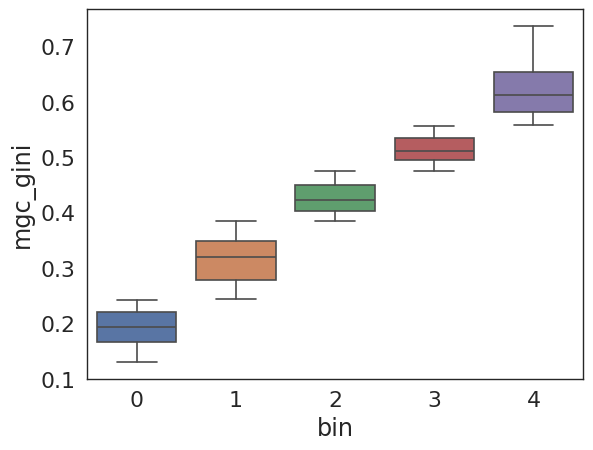

In [ ]:
sns.boxplot(mgc_gini, y = 'mgc_gini', x = 'bin')

In [ ]:
merged_mges = pd.merge(merged, mgc_gini, left_on='id', right_index= True)
merged_mges['mgc_pow'] =  merged_mges['mgc_gini'] **2
merged_mges

,id,bootstrap,auc_sim,auc_bulk,auc_sim_pow2,meta,pred,mgc_gini,bin,mgc_pow
0,GO:0000045,3,0.537387,0.524639,0.288785,Non Brain,0.599314,0.205555,0,0.042253
1,GO:0000045,5,0.563274,0.508492,0.317278,Non Brain,0.604255,0.205555,0,0.042253
2,GO:0000045,1,0.558774,0.585574,0.312228,Non Brain,0.603396,0.205555,0,0.042253
3,GO:0000045,4,0.554706,0.547592,0.307698,Non Brain,0.602620,0.205555,0,0.042253
4,GO:0000045,2,0.535530,0.501083,0.286792,Non Brain,0.598960,0.205555,0,0.042253
...,...,...,...,...,...,...,...,...,...,...
136295,GO:2001244,93,0.516547,0.670127,0.266821,Non Brain,0.595336,0.334780,1,0.112078
136296,GO:2001244,96,0.542822,0.662114,0.294656,Non Brain,0.600352,0.334780,1,0.112078
136297,GO:2001244,97,0.426631,0.699755,0.182014,Non Brain,0.578174,0.334780,1,0.112078
136298,GO:2001244,100,0.464323,0.665889,0.215595,Non Brain,0.585368,0.334780,1,0.112078


In [ ]:
model = mixedlm(formula = 'auc_bulk ~ auc_sim*bin + auc_sim_pow2*bin', data = merged_mges, groups = merged['bootstrap']).fit()
model.summary()

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
============================================================
Model:             MixedLM  Dependent Variable:  auc_bulk   
No. Observations:  136300   Method:              REML       
No. Groups:        100      Scale:               0.0063     
Min. group size:   1363     Log-Likelihood:      151779.3331
Max. group size:   1363     Converged:           Yes        
Mean group size:   1363.0                                   
------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         0.874    0.018  48.047 0.000  0.838  0.909
auc_sim          -1.353    0.073 -18.659 0.000 -1.495 -1.211
bin              -0.024    0.006  -3.750 0.000 -0.036 -0.011
auc_sim:bin       0.148    0.024   6.069 0.000  0.100  0.195
auc_sim_pow2      1.454    0.072  20.197 0.000  1.313  1.595
auc_sim_pow2:bin -0.144    0.024  -6.135 0.000 -0.190 -0.098
Group Var         0.000    0.000                            
============================================================

"""

In [ ]:
merged_mges['pred'] = model.predict(merged_mges)
merged_agg = merged_mges.groupby(['id', 'meta', 'bin'])[['auc_sim', 'auc_bulk', 'pred']].mean().dropna().reset_index()
merged_agg


/tmp/ipykernel_2288338/1132702113.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_agg = merged_mges.groupby(['id', 'meta', 'bin'])[['auc_sim', 'auc_bulk', 'pred']].mean().dropna().reset_index()


,id,meta,bin,auc_sim,auc_bulk,pred
0,GO:0000045,Non Brain,0,0.545295,0.533097,0.569172
1,GO:0000070,Non Brain,1,0.500938,0.614372,0.577523
2,GO:0000077,Non Brain,0,0.487778,0.534832,0.561685
3,GO:0000079,Non Brain,2,0.471284,0.533447,0.587956
4,GO:0000082,Non Brain,1,0.473454,0.496004,0.574430
...,...,...,...,...,...,...
1358,GO:2001237,Non Brain,1,0.474204,0.512544,0.573755
1359,GO:2001238,Non Brain,2,0.420278,0.683818,0.589523
1360,GO:2001240,Non Brain,2,0.477814,0.558692,0.589258
1361,GO:2001243,Non Brain,1,0.535729,0.569002,0.582909


/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option i

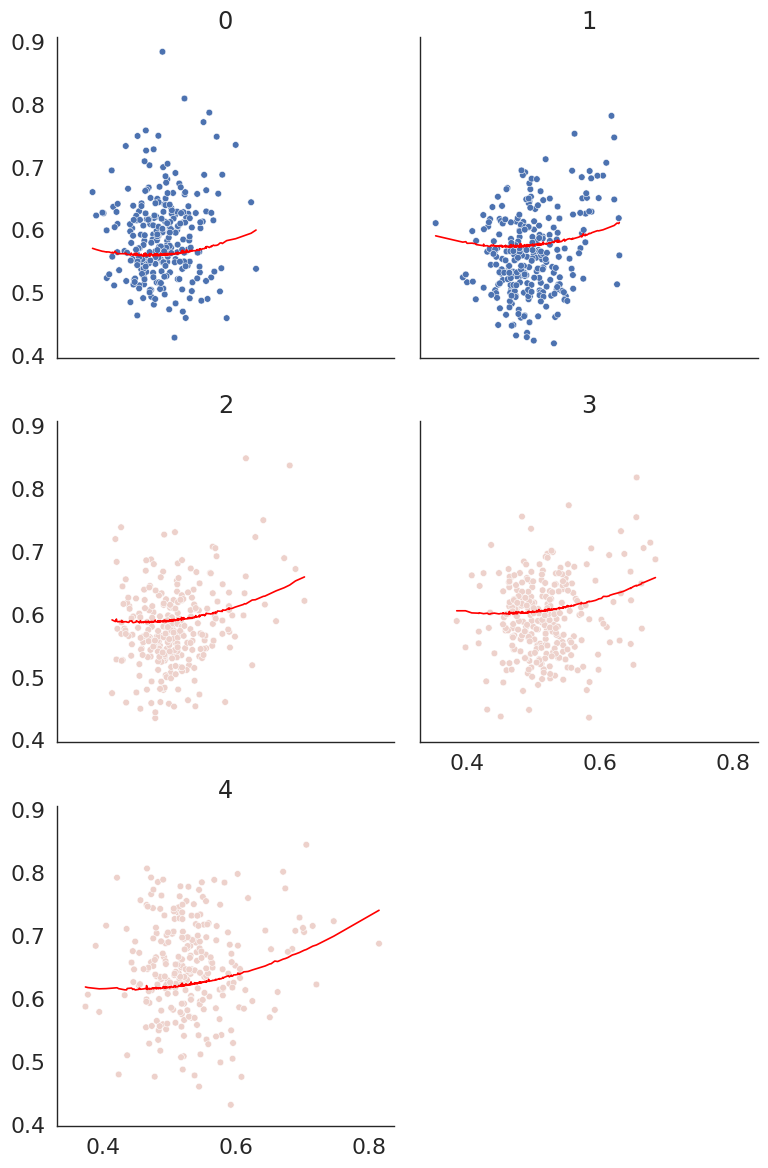

In [ ]:
# Faceted scatterplot
g = sns.FacetGrid(merged_agg, col='bin', col_wrap=2, height=4)
g.map_dataframe(sns.scatterplot, x='auc_sim', y='auc_bulk', hue = 'bin', legend=False)
g.map_dataframe(sns.lineplot, x='auc_sim', y='pred', color = 'red', legend=False)

# Customize titles
g.set_titles(col_template="{col_name}")
# Remove titles and axis labels
g.set_axis_labels("", "")
plt.tight_layout()
plt.savefig("figs/bulk_sc_corr.svg", dpi = 300)
plt.show()